# Process coordinates

In [1]:
from wings.detection.dataset import collect_image_paths
from wings.config import RAW_DATA_DIR, COUNTRIES

image_paths = collect_image_paths(RAW_DATA_DIR, COUNTRIES)
import random

sample_path = random.choice(image_paths)
sample_path

2026-04-25 09:15:29.959 | INFO     | wings.config:<module>:40 - PROJ_ROOT path is: C:\Users\X\projects\bees
2026-04-25 09:15:31.815 | INFO     | wings.config:<module>:64 - torch.cuda.get_device_name()='NVIDIA RTX A3000 12GB Laptop GPU'


2026-04-25 09:15:33.339 | INFO     | wings.detection.dataset:collect_image_paths:30 - Collecting image paths from: C:\Users\X\projects\bees\data\raw


WindowsPath('C:/Users/X/projects/bees/data/raw/PL-wing-images/PL-0084-000677-L.dw.png')

In [4]:
from ultralytics import YOLO
from wings.config import MODELS_DIR


# yolo_model = YOLO(MODELS_DIR / "trained_yolo.pt").to("cuda")
yolo_model = YOLO(MODELS_DIR / "best.pt").to("cuda")

C:\Users\X\projects\bees\data\raw\HR-wing-images\HR-0002-005-101736-R.dw.png
[194 212 261 261 261 329 385 367 408 377 417 423 436 449 490 571 599 610  67] [143 144  65 118 204  61  28  51  86 107 145 185 219  38  79 123 124 155  66]


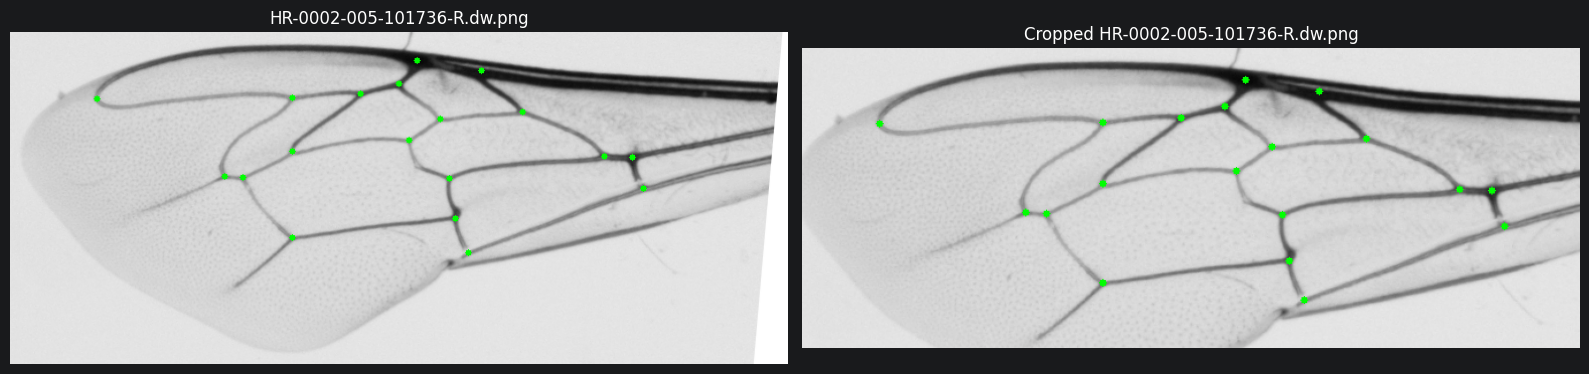

In [128]:
import random
import cv2
import matplotlib.pyplot as plt
from wings.detection.dataset import read_coordinates
import numpy as np
from pathlib import Path

sample_path = random.choice(image_paths)
# sample_path = Path("C:\\Users\\X\\projects\\bees\\data\\raw\\GR-wing-images\\GR-0050-2004-MA-XL-07-6.dw.png")
# sample_path = Path("C:\\Users\\X\\projects\\bees\\data\\raw\\GR-wing-images\\GR-0114-2005-TR-024-5.dw.png")
print(sample_path)
img = cv2.imread(str(sample_path))
img_coords = img.copy()

x_coords, y_coords = read_coordinates(sample_path, img)
for x, y in zip(x_coords, y_coords):
    x, y = int(x), int(y)
    cv2.circle(img_coords, (x, y), 3, (0, 255, 0), -1)
img_coords_rgb = cv2.cvtColor(img_coords, cv2.COLOR_BGR2RGB)



result = yolo_model(img)[0]
if len(result) > 0:
    boxes = result.boxes.cpu().numpy()
    conf = boxes.conf
    x1, y1, x2, y2 = boxes.xyxy[np.argmax(conf)]

    xmin, xmax = int(min(x1, x2)), int(max(x1, x2))
    ymin, ymax = int(min(y1, y2)), int(max(y1, y2))

    img = img[ymin:ymax, xmin:xmax]
    x_coords = x_coords - xmin
    y_coords = y_coords - ymin
    for x, y in zip(x_coords, y_coords):
        x, y = int(x), int(y)
        cv2.circle(img, (x, y), 3, (0, 255, 0), -1)
    print(x_coords, y_coords)
    
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)



fig, axs = plt.subplots(1, 2, figsize=(16, 12))
axs[0].imshow(img_coords_rgb)
axs[0].set_title(f"{sample_path.name}")
axs[0].axis("off")
axs[1].imshow(img_rgb)
axs[1].set_title(f"Cropped {sample_path.name}")
axs[1].axis("off")
plt.tight_layout()
plt.show()

# Visualize unet input cropped images

## Select dataset

In [204]:
from wings.detection.dataset import collect_image_paths
from wings.config import RAW_DATA_DIR, COUNTRIES
import random
import os

all_files = collect_image_paths(RAW_DATA_DIR, COUNTRIES)

# directory = RAW_DATA_DIR / "pulawy" / "01_00_01"
directory = RAW_DATA_DIR / "skrzydła-BM" / "j"

all_files = []
for subdir, _, files in os.walk(directory):
    for file in files:
        if file.lower().endswith('.png'):
            all_files.append(Path(os.path.join(subdir, file)))

sample_path = random.choice(all_files)
sample_path

2026-04-25 12:33:46.405 | INFO     | wings.detection.dataset:collect_image_paths:30 - Collecting image paths from: C:\Users\X\projects\bees\data\raw


WindowsPath('C:/Users/X/projects/bees/data/raw/skrzydła-BM/j/5.d.dw.dw.png.dw.png')

In [63]:
# yolo_model = YOLO(MODELS_DIR / "trained_yolo.pt").to("cuda")
yolo_model = YOLO(MODELS_DIR / "best.pt").to("cuda")

## Only images

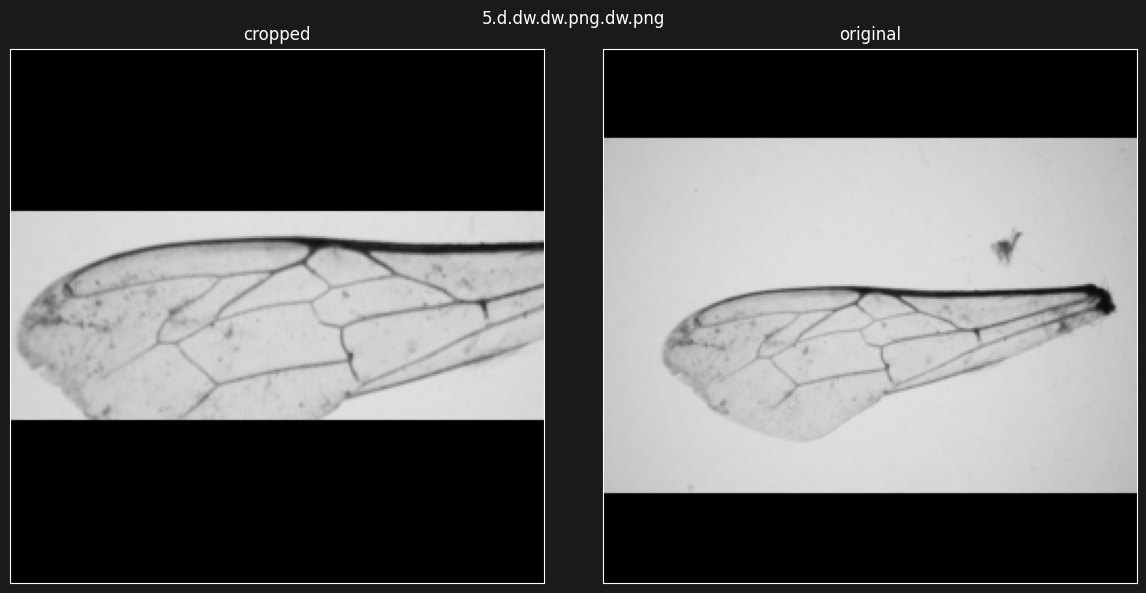

In [211]:
import numpy as np
import torch
import torchvision.transforms.functional as F


sample_path = random.choice(all_files)

img = cv2.imread(str(sample_path))
base_img = img.copy()

result = yolo_model(img)[0]
if len(result) > 0:
    boxes = result.boxes.cpu().numpy()
    conf = boxes.conf
    x1, y1, x2, y2 = boxes.xyxy[np.argmax(conf)]

    xmin, xmax = int(min(x1, x2)), int(max(x1, x2))
    ymin, ymax = int(min(y1, y2)), int(max(y1, y2))

    img = img[ymin:ymax, xmin:xmax]

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = torch.from_numpy(img).permute(2, 0, 1).contiguous()

img = F.resize(img, 255, interpolation=F.InterpolationMode.BILINEAR, antialias=True, max_size=256)
_, h, w = img.shape
if w >= h:
    pad_left = 0
    pad_top = (256 - h) // 2
    pad_right = 0
    pad_bottom = 256 - h - pad_top
else:
    pad_left = (256 - w) // 2
    pad_top = 0
    pad_right = 256 - w - pad_left
    pad_bottom = 0
img = F.pad(img, [pad_left, pad_top, pad_right, pad_bottom], padding_mode='constant', fill=0)
img = F.convert_image_dtype(img, torch.float)
img = img.numpy().transpose(1, 2, 0)

base_img = cv2.cvtColor(base_img, cv2.COLOR_BGR2RGB)
base_img = torch.from_numpy(base_img).permute(2, 0, 1).contiguous()

base_img = F.resize(base_img, 255, interpolation=F.InterpolationMode.BILINEAR, antialias=True, max_size=256)
_, h, w = base_img.shape
if w >= h:
    pad_left = 0
    pad_top = (256 - h) // 2
    pad_right = 0
    pad_bottom = 256 - h - pad_top
else:
    pad_left = (256 - w) // 2
    pad_top = 0
    pad_right = 256 - w - pad_left
    pad_bottom = 0
base_img = F.pad(base_img, [pad_left, pad_top, pad_right, pad_bottom], padding_mode='constant', fill=0)
base_img = F.convert_image_dtype(base_img, torch.float)
base_img = base_img.numpy().transpose(1, 2, 0)


fig, ax = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(f"{sample_path.name}")
ax[0].imshow(img, cmap="gray")
ax[0].set_title("cropped")
ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].imshow(base_img, cmap="gray")
ax[1].set_title("original")
ax[1].set_xticks([])
ax[1].set_yticks([])
plt.tight_layout()
plt.show()

# Calculate statistics

In [64]:
from wings.modeling.loss import DiceLoss
from wings.modeling.litnet import LitNet
from wings.config import PROCESSED_DATA_DIR, MODELS_DIR
import torch

mean_coords = torch.load(
    PROCESSED_DATA_DIR / "mask_datasets" / 'rectangle' / "mean_shape.pth", weights_only=False
)

checkpoint_path = MODELS_DIR / 'unet-rectangle-epoch=08-val_loss=0.14-unet-training-rectangle_1.ckpt'
unet_model = torch.hub.load(
    'mateuszbuda/brain-segmentation-pytorch', 'unet',
    in_channels=3, out_channels=1, init_features=32, pretrained=False
)
num_epochs = 60
model = LitNet.load_from_checkpoint(checkpoint_path, model=unet_model, num_epochs=num_epochs, criterion=DiceLoss())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()
device



W0425 09:20:18.721000 23036 .venv\Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Using cache found in C:\Users\X/.cache\torch\hub\mateuszbuda_brain-segmentation-pytorch_master


device(type='cuda')

## Test Dataset

In [65]:
from tqdm import tqdm
from wings.config import RAW_DATA_DIR, IMG_FOLDER_SUFX

test_dataset = torch.load(
    PROCESSED_DATA_DIR / "mask_datasets" / 'rectangle' / "test_mask_dataset.pth",
    weights_only=False
)
original_dataset = test_dataset.dataset  # this gives you the original dataset

all_files = []
for idx in tqdm(range(len(test_dataset)), desc="Processing paths"):
    filename = original_dataset.coords_df.loc[test_dataset.indices[idx], 'file']
    country = filename.split('-', 1)[0]

    file_path = RAW_DATA_DIR / f"{country}{IMG_FOLDER_SUFX}" / filename
    all_files.append(file_path)

len(all_files)
# all_files = [Path("C:\\Users\\X\\projects\\bees\\data\\raw\\GR-wing-images\\GR-0114-2005-TR-024-5.dw.png")]

Processing paths: 100%|██████████| 2172/2172 [00:00<00:00, 166871.73it/s]


2172

In [66]:
from wings.gpa import handle_coordinates
from wings.visualizing.image_preprocess import final_coords, unet_fit_rectangle_preprocess
import torch
import numpy as np
from tqdm import tqdm

original_labels = [[] for _ in range(5)]
predicted_labels = [[] for _ in range(5)]
points_indices = [[] for _ in range(5)]
negative_coords = []

for idx, img_path in enumerate(tqdm(all_files, desc="Processing images")):
    img = cv2.imread(str(img_path))
    x_coords, y_coords = read_coordinates(img_path, img)
    result = yolo_model.predict(img, verbose=False)[0]
    if len(result) > 0:
        boxes = result.boxes.cpu().numpy()
        conf = boxes.conf
        x1, y1, x2, y2 = boxes.xyxy[np.argmax(conf)]

        xmin, xmax = int(min(x1, x2)), int(max(x1, x2))
        ymin, ymax = int(min(y1, y2)), int(max(y1, y2))

        img = img[ymin:ymax, xmin:xmax]
        x_coords = x_coords - xmin
        y_coords = y_coords - ymin
    
    if (x_coords < 0).any() or (y_coords < 0).any():
        negative_coords.append(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = torch.from_numpy(img).permute(2, 0, 1).contiguous()
    x_size, y_size = img_tensor.shape[2], img_tensor.shape[1]
    image_tensor, _, _ = unet_fit_rectangle_preprocess(img_tensor)
    
    output = model(image_tensor.cuda().unsqueeze(0))
    mask = torch.round(output).squeeze().detach().cpu().numpy()
    mask_coords = final_coords(mask, x_size, y_size)
    mask_coords = torch.tensor(mask_coords)
    n_points = len(mask_coords)    

    if n_points < 18:
        idx_group = 0
    elif n_points == 18:
        idx_group = 1
    elif n_points == 19:
        idx_group = 2
    elif n_points == 20:
        idx_group = 3
    else:
        idx_group = 4

    reordered = handle_coordinates(mask_coords, mean_coords).cpu().numpy()
    x_coords = torch.tensor(x_coords)
    y_coords = torch.tensor(y_coords)
    y_coords = y_size - y_coords - 1
    orig = torch.stack((x_coords, y_coords), dim=1)


    points_indices[idx_group].append(img_path)
    original_labels[idx_group].append(orig.cpu().numpy())
    predicted_labels[idx_group].append(reordered)



original_labels = [np.stack(lbls) if len(lbls) > 0 else np.empty((0, 2)) for lbls in original_labels]
predicted_labels = [
    np.stack(lbls) if len(lbls) > 0 else np.empty((0, 0, 2)) for lbls in predicted_labels
]


total_samples_num = len(all_files)
failed_samples_num = sum(len(points_indices[i]) for i in [0, 1, 3, 4])  # exclude 19-points group

print(f"Total samples: {total_samples_num}")
print(f"Failed masks: {failed_samples_num}")

for i, n_points in enumerate(range(17, 22)):
    print(f"predicted_labels_{n_points}.shape = {predicted_labels[i].shape}")


Processing images: 100%|██████████| 2172/2172 [02:17<00:00, 15.82it/s]

Total samples: 2172
Failed masks: 62
predicted_labels_17.shape = (1, 19, 2)
predicted_labels_18.shape = (29, 19, 2)
predicted_labels_19.shape = (2110, 19, 2)
predicted_labels_20.shape = (29, 19, 2)
predicted_labels_21.shape = (3, 19, 2)


In [67]:
errors = []
for i in range(5):
    if len(predicted_labels[i]) == 0 or len(original_labels[i]) == 0:
        errors.append(np.empty((0, 0)))
        continue
    err = np.linalg.norm(predicted_labels[i] - original_labels[i], axis=2)
    errors.append(err)

# Compute means and medians
for i, n_points in enumerate(range(17, 22)):
    if errors[i].size == 0:
        print(f"{n_points}-point group: no samples available.")
        continue
    mean_val = errors[i].mean()
    median_val = np.median(errors[i])
    num_img = len(errors[i])  # total number of point-wise errors

    print(f"mean{n_points}={mean_val:.4f}\tmedian{n_points}={median_val:.4f}\t\timages={num_img}")



# ---- GLOBAL ERROR ACROSS ALL GROUPS ----
# Flatten all non-empty error arrays into a single array
all_errors = np.concatenate([e.flatten() for e in errors if e.size > 0])

if all_errors.size > 0:
    global_mean = all_errors.mean()
    global_median = np.median(all_errors)
    print(f"\nGLOBAL MEAN ERROR = {global_mean:.4f}")
    print(f"GLOBAL MEDIAN ERROR = {global_median:.4f}")
else:
    print("\nNo valid error data available for global computation.")

mean17=1.3641	median17=1.0695		images=1
mean18=1.8643	median18=1.5768		images=29
mean19=1.6306	median19=1.5065		images=2110
mean20=1.7222	median20=1.5842		images=29
mean21=4.3512	median21=2.2622		images=3

GLOBAL MEAN ERROR = 1.6386
GLOBAL MEDIAN ERROR = 1.5089


In [68]:
print(len(negative_coords))

0


# Visualize

In [71]:
values = points_indices[1]
values_iter = iter(values)
max_n = len(values)
max_n


29

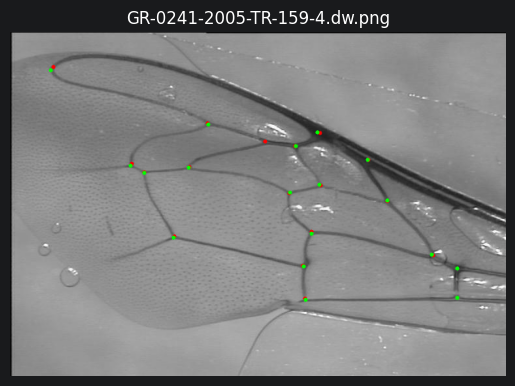

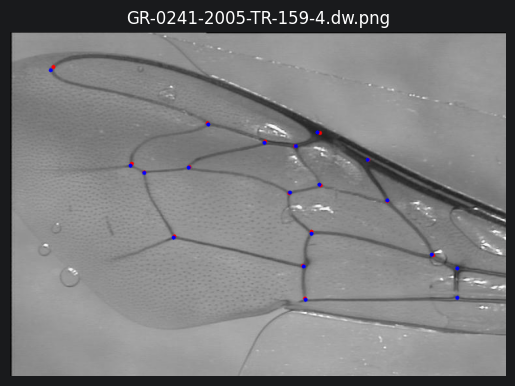

In [123]:
from wings.visualizing.visualize import visualize_coords


try:
    sample_path = next(values_iter)
except StopIteration:
    values_iter = iter(values)
    sample_path = next(values_iter)

img = cv2.imread(str(sample_path))
x_coords, y_coords = read_coordinates(sample_path, img)
result = yolo_model.predict(img, verbose=False)[0]
if len(result) > 0:
    boxes = result.boxes.cpu().numpy()
    conf = boxes.conf
    x1, y1, x2, y2 = boxes.xyxy[np.argmax(conf)]

    xmin, xmax = int(min(x1, x2)), int(max(x1, x2))
    ymin, ymax = int(min(y1, y2)), int(max(y1, y2))

    img = img[ymin:ymax, xmin:xmax]
    x_coords = x_coords - xmin
    y_coords = y_coords - ymin

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_tensor = torch.from_numpy(img).permute(2, 0, 1).contiguous()
x_size, y_size = img_tensor.shape[2], img_tensor.shape[1]
image_tensor, _, _ = unet_fit_rectangle_preprocess(img_tensor)

output = model(image_tensor.cuda().unsqueeze(0))
mask = torch.round(output).squeeze().detach().cpu().numpy()
mask_coords = final_coords(mask, x_size, y_size)
mask_coords = torch.tensor(mask_coords)

reordered = handle_coordinates(mask_coords, mean_coords).cpu().numpy()
x_coords = torch.tensor(x_coords)
y_coords = torch.tensor(y_coords)
y_coords = y_size - y_coords - 1
orig = torch.stack((x_coords, y_coords), dim=1)

spot_size = 3
img = visualize_coords(img, orig.flatten(), spot_size=spot_size, color=(255, 0, 0), show=False)
img = visualize_coords(img, mask_coords.flatten(), spot_size=spot_size, color=(0, 255, 0), filename=f"{sample_path.name}")
img2 = visualize_coords(img, reordered.flatten(), spot_size=spot_size, color=(0, 0, 255), filename=f"{sample_path.name}")

## Puławy

In [160]:
from wings.config import RAW_DATA_DIR
import random
import os
from PIL import Image


directory = RAW_DATA_DIR / "pulawy" / "01_00_01"

all_files = []
for subdir, _, files in os.walk(directory):
    for file in files:
        if file.lower().endswith(".png"):
            path = Path(os.path.join(subdir, file))

            with Image.open(path) as img:
                x_size, y_size = img.size

            if x_size == 5782:
                continue

            all_files.append(path)


sample_path = random.choice(all_files)
sample_path

WindowsPath('C:/Users/X/projects/bees/data/raw/pulawy/01_00_01/01_00_32/01_00_856.png')

In [161]:
from PIL import Image
from wings.gpa import handle_coordinates
from wings.visualizing.image_preprocess import final_coords, unet_fit_rectangle_preprocess
import torch
import numpy as np
from tqdm import tqdm

original_labels = [[] for _ in range(5)]
predicted_labels = [[] for _ in range(5)]
points_indices = [[] for _ in range(5)]
negative_coords = []

for idx, img_path in enumerate(tqdm(all_files, desc="Processing images")):
    img = Image.open(img_path)
    img.load()
    meta = img.info['IdentiFly']
    orig = meta.split("landmarks:")[1].split(";")[0]
    labels = np.array([int(x) for x in orig.split()])
    x_coords, y_coords = labels[::2], labels[1::2]
    img = cv2.imread(str(img_path))
    result = yolo_model.predict(img, verbose=False)[0]
    if len(result) > 0:
        boxes = result.boxes.cpu().numpy()
        conf = boxes.conf
        x1, y1, x2, y2 = boxes.xyxy[np.argmax(conf)]

        xmin, xmax = int(min(x1, x2)), int(max(x1, x2))
        ymin, ymax = int(min(y1, y2)), int(max(y1, y2))

        img = img[ymin:ymax, xmin:xmax]
        x_coords = x_coords - xmin
        y_coords = y_coords - ymin

    if (x_coords < 0).any() or (y_coords < 0).any():
        negative_coords.append(img_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_tensor = torch.from_numpy(img).permute(2, 0, 1).contiguous()
    x_size, y_size = img_tensor.shape[2], img_tensor.shape[1]
    image_tensor, _, _ = unet_fit_rectangle_preprocess(img_tensor)

    output = model(image_tensor.cuda().unsqueeze(0))
    mask = torch.round(output).squeeze().detach().cpu().numpy()
    mask_coords = final_coords(mask, x_size, y_size)
    mask_coords = torch.tensor(mask_coords)
    n_points = len(mask_coords)

    if n_points < 18:
        idx_group = 0
    elif n_points == 18:
        idx_group = 1
    elif n_points == 19:
        idx_group = 2
    elif n_points == 20:
        idx_group = 3
    else:
        idx_group = 4

    reordered = handle_coordinates(mask_coords, mean_coords).cpu().numpy()
    x_coords = torch.tensor(x_coords)
    y_coords = torch.tensor(y_coords)
    y_coords = y_size - y_coords - 1
    orig = torch.stack((x_coords, y_coords), dim=1)


    points_indices[idx_group].append(img_path)
    original_labels[idx_group].append(orig.cpu().numpy())
    predicted_labels[idx_group].append(reordered)



original_labels = [np.stack(lbls) if len(lbls) > 0 else np.empty((0, 2)) for lbls in original_labels]
predicted_labels = [
    np.stack(lbls) if len(lbls) > 0 else np.empty((0, 0, 2)) for lbls in predicted_labels
]


total_samples_num = len(all_files)
failed_samples_num = sum(len(points_indices[i]) for i in [0, 1, 3, 4])  # exclude 19-points group

print(f"Total samples: {total_samples_num}")
print(f"Failed masks: {failed_samples_num}")

for i, n_points in enumerate(range(17, 22)):
    print(f"predicted_labels_{n_points}.shape = {predicted_labels[i].shape}")


Processing images: 100%|██████████| 1012/1012 [00:36<00:00, 27.65it/s]

Total samples: 1012
Failed masks: 140
predicted_labels_17.shape = (0, 0, 2)
predicted_labels_18.shape = (6, 19, 2)
predicted_labels_19.shape = (872, 19, 2)
predicted_labels_20.shape = (120, 19, 2)
predicted_labels_21.shape = (14, 19, 2)


In [162]:
len(negative_coords)

0

In [163]:
errors = []
for i in range(5):
    if len(predicted_labels[i]) == 0 or len(original_labels[i]) == 0:
        errors.append(np.empty((0, 0)))
        continue
    err = np.linalg.norm(predicted_labels[i] - original_labels[i], axis=2)
    errors.append(err)

# Compute means and medians
for i, n_points in enumerate(range(17, 22)):
    if errors[i].size == 0:
        print(f"{n_points}-point group: no samples available.")
        continue
    mean_val = errors[i].mean()
    median_val = np.median(errors[i])
    num_img = len(errors[i])  # total number of point-wise errors

    print(f"mean{n_points}={mean_val:.4f}\tmedian{n_points}={median_val:.4f}\t\timages={num_img}")



# ---- GLOBAL ERROR ACROSS ALL GROUPS ----
# Flatten all non-empty error arrays into a single array
all_errors = np.concatenate([e.flatten() for e in errors if e.size > 0])

if all_errors.size > 0:
    global_mean = all_errors.mean()
    global_median = np.median(all_errors)
    print(f"\nGLOBAL MEAN ERROR = {global_mean:.4f}")
    print(f"GLOBAL MEDIAN ERROR = {global_median:.4f}")
else:
    print("\nNo valid error data available for global computation.")

17-point group: no samples available.
mean18=7.4043	median18=2.3564		images=6
mean19=2.6454	median19=2.0002		images=872
mean20=2.6036	median20=2.0111		images=120
mean21=2.5748	median21=1.9804		images=14

GLOBAL MEAN ERROR = 2.6677
GLOBAL MEDIAN ERROR = 2.0013
